In [1]:
import metaworld
from metaworld.envs import ALL_V2_ENVIRONMENTS_GOAL_OBSERVABLE 

In [2]:
import numpy as np
from scipy.spatial.transform import Rotation as R

# Function assisted with ChatGPT
def quaternion_to_tipping_angle(quaternion):
    # Convert to x, y, z, w
    quaternion = [quaternion[1], quaternion[2], quaternion[3], quaternion[0]]
    r = R.from_quat(quaternion)
    
    global_up = np.array([0, 0, 1])
    local_up = r.apply(global_up)
    
    # Compute the angle between local up and global up
    cos_theta = np.dot(local_up, global_up) / (np.linalg.norm(local_up) * np.linalg.norm(global_up))
    theta = np.arccos(np.clip(cos_theta, -1.0, 1.0))  # Clip to avoid numerical issues
    
    # Convert to degrees if needed
    angle_degrees = np.degrees(theta)
    
    return angle_degrees

In [3]:
import imageio.v3 as iio
import random
import numpy as np
# from metaworld.policies.sawyer_stick_pull_v2_policy import SawyerStickPullV2Policy as p

# Initialize the environment
# env = basketball_cls(render_mode="rgb_array", camera_name="corner")

ml1 = metaworld.ML1('safe-stick-pull') # Construct the benchmark, sampling tasks
env = ml1.train_classes['safe-stick-pull'](render_mode="rgb_array", camera_name="corner") 
# print(ml1.train_tasks)
task = random.choice(ml1.train_tasks)
# print(task)
env.set_task(task)  
obs, info = env.reset()
env._partially_observable = False
done = False
rewards = []
costs = []
qpos = []
states = []

# policy = p()

# List to store frames
frames = []

i = 0
while not done:
    # action = policy.get_action(obs)
    action = env.action_space.sample()
    action = np.array([0.5, 1, -0.5, 0])
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()  # Capture frame as RGB array
    frames.append(np.flipud(frame))  # Add frame to the list
    done = terminated or truncated or (int(info['success']) == 1) or i > 50
    i += 1
    rewards.append(reward)
    costs.append(info['unscaled_cost'])
    qpos.append(env.data.qpos.copy())
    states.append(obs[18:21])

# Save the video
iio.imwrite("basketball_simulation.mp4", frames, fps=30)  # Adjust fps if necessary

env.close()


In [4]:
np.array(qpos).shape

(52, 23)

[16 17 18]


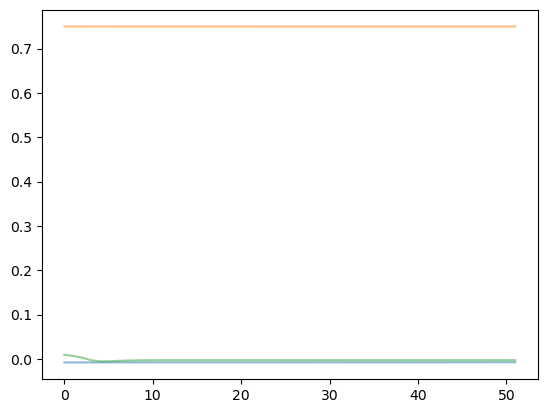

In [5]:
import matplotlib.pyplot as plt

search_range = np.arange(0, 3) + 16
print(search_range)

plt.plot(np.array(qpos)[:, search_range], alpha=0.5)

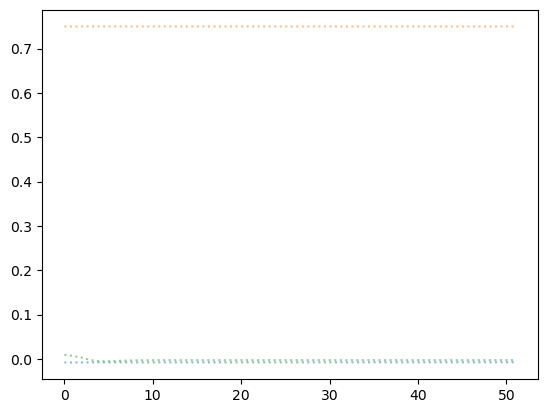

In [6]:
plt.plot(np.array(states), alpha=0.5, linestyle=':')


In [7]:
print(sum(rewards))
print(sum(costs))

2.9687630297891645
0.0


Text(0.5, 0, 'Simulation Timestep')

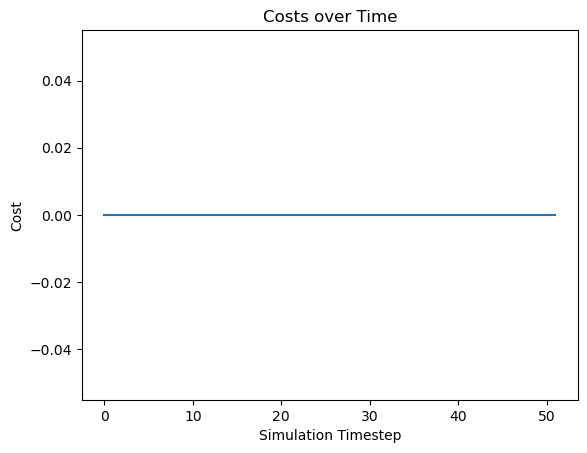

In [8]:
import matplotlib.pyplot as plt

plt.title("Costs over Time")
plt.plot(costs)
plt.ylabel("Cost")
plt.xlabel("Simulation Timestep")